In [ ]:
import numpy as np
import pandas as pd
from datetime import datetime

from satellite_downlink_simulator.simulation import SpectrumRecord
from satellite_downlink_simulator import (
    carrier_generator,
    interferer_generator,
    psd_simulator,
    visualization,
    spectrum_records_utility
)

# Extract classes/functions for convenience
CarrierGenerator = carrier_generator.CarrierGenerator
InterfererGenerator = interferer_generator.InterfererGenerator
PSDSimulator = psd_simulator.PSDSimulator
Visualizer = visualization.Visualizer
load_and_process_records = spectrum_records_utility.load_and_process_records

In [6]:
carrier_gen = CarrierGenerator(seed=42)
carrier_config = carrier_gen.generate_carriers(
    num_static_per_xpdr=(0, 10),  # Fewer carriers for quick test
    num_dynamic=5
)

simulator = PSDSimulator(
    carrier_config=carrier_config,
    interferer_configs=[],
    rbw_hz=100e3,  # 100 kHz RBW for faster generation
    vbw_hz=1e3
)

start_time = datetime(2025, 1, 15, 0, 0, 0)  # Fixed time for testing
output_filepath = f"../dev_output/spectrum_records_{start_time.strftime('%Y%m%d-%H%M%S')}.json"

snapshots, metadata = simulator.run_simulation(
    duration_min=60*60,  # 60 minutes
    snapshot_interval_min=1,  # 1 minute intervals
    start_datetime=start_time,
    export_json=True,
    output_filepath=output_filepath
)

print(f"Output saved to: {output_filepath}")

Generating static carriers...
  Created 14 static carriers
Generating 5 dynamic carriers...
  Created 5 dynamic carriers
Total carriers: 19
Initialized simulator with 6 transponders
  RBW: 100.0 kHz, VBW: 1.0 kHz

Running 60.0-hour simulation...
  Snapshot interval: 1.0 min
  Total snapshots: 3601
  Processing t=0.0 hrs (1/3601 snapshots, 0%)
  Processing t=0.2 hrs (13/3601 snapshots, 0%)
  Processing t=0.4 hrs (25/3601 snapshots, 1%)
  Processing t=0.6 hrs (37/3601 snapshots, 1%)
  Processing t=0.8 hrs (49/3601 snapshots, 1%)
  Processing t=1.0 hrs (61/3601 snapshots, 2%)
  Processing t=1.2 hrs (73/3601 snapshots, 2%)
  Processing t=1.4 hrs (85/3601 snapshots, 2%)
  Processing t=1.6 hrs (97/3601 snapshots, 3%)
  Processing t=1.8 hrs (109/3601 snapshots, 3%)
  Processing t=2.0 hrs (121/3601 snapshots, 3%)
  Processing t=2.2 hrs (133/3601 snapshots, 4%)
  Processing t=2.4 hrs (145/3601 snapshots, 4%)
  Processing t=2.6 hrs (157/3601 snapshots, 4%)
  Processing t=2.8 hrs (169/3601 snapsh

In [7]:
records = SpectrumRecord.from_file(output_filepath)

In [8]:
data_rows = []
for record in records:
    freq_start = record.cf_hz - (record.bw_hz / 2)
    freq_end = record.cf_hz + (record.bw_hz / 2)
    frequencies = np.linspace(freq_start, freq_end, record.psd_shape[0])
    powers = record.get_psd()
    
    data_rows.append({
        'timestamp': record.timestamp,
        'cf_hz': record.cf_hz,
        'bw_hz': record.bw_hz,
        'rbw_hz': record.rbw_hz,
        'vbw_hz': record.vbw_hz,
        'frequencies': frequencies,
        'powers': powers
    })

df = pd.DataFrame(data_rows)
df = df.set_index('timestamp')

In [9]:
# Quick viz 
time_array, frequency_array, psd_array, metadata, activity_log, interferer_data = load_and_process_records(output_filepath)

Loading spectrum records from: ../dev_output/spectrum_records_20250115-000000.json
  Loaded 3601 spectrum records
  Time range: 0.0 - 3600.0 minutes
  Frequency range: 12.200 - 12.416 GHz
  Frequency points: 2166
  Decompressing PSD data...
    Processing record 50/3601
    Processing record 100/3601
    Processing record 150/3601
    Processing record 200/3601
    Processing record 250/3601
    Processing record 300/3601
    Processing record 350/3601
    Processing record 400/3601
    Processing record 450/3601
    Processing record 500/3601
    Processing record 550/3601
    Processing record 600/3601
    Processing record 650/3601
    Processing record 700/3601
    Processing record 750/3601
    Processing record 800/3601
    Processing record 850/3601
    Processing record 900/3601
    Processing record 950/3601
    Processing record 1000/3601
    Processing record 1050/3601
    Processing record 1100/3601
    Processing record 1150/3601
    Processing record 1200/3601
    Process

In [10]:
viz = Visualizer(
    time_array=time_array,
    frequency_array=frequency_array,
    psd_array=psd_array,
    metadata=metadata,
    output_dir="../dev_output/"
)

Initialized visualizer
  Time range: 0.0 - 60.0 hrs
  Frequency range: 12.200 - 12.416 GHz
  PSD shape: (3601, 2166)


In [11]:
viz.create_waterfall_plot()


Creating waterfall plot...
  PSD range: -121.0 to -94.8 dBm/Hz
  Saved to ../dev_output/waterfall_plot.png


In [13]:
# Run 10 different simulations with varying parameters
from datetime import timedelta

num_simulations = 10
simulation_duration_min = 60  # 1 hour per simulation
all_dataframes = []
current_start_time = datetime(2025, 1, 15, 0, 0, 0)

# Define parameter variations
np.random.seed(42)
static_ranges = [(2, 8), (3, 10), (1, 5), (4, 12), (2, 7), (3, 9), (1, 6), (5, 10), (2, 9), (3, 8)]
dynamic_counts = [3, 5, 7, 4, 6, 8, 5, 4, 6, 7]

print(f"Running {num_simulations} simulations with varying carrier configurations...\n")

for i in range(num_simulations):
    print(f"=== Simulation {i+1}/{num_simulations} ===")
    print(f"  Static carriers per transponder: {static_ranges[i]}")
    print(f"  Dynamic carriers: {dynamic_counts[i]}")
    print(f"  Start time: {current_start_time}")
    
    # Generate carrier configuration
    carrier_gen = CarrierGenerator(seed=42 + i)
    carrier_config = carrier_gen.generate_carriers(
        num_static_per_xpdr=static_ranges[i],
        num_dynamic=dynamic_counts[i]
    )
    
    # Create simulator
    simulator = PSDSimulator(
        carrier_config=carrier_config,
        interferer_configs=[],
        rbw_hz=100e3,
        vbw_hz=1e3
    )
    
    # Run simulation
    output_filepath = f"../dev_output/sim_{i+1:02d}_{current_start_time.strftime('%Y%m%d-%H%M%S')}.json"
    snapshots, metadata = simulator.run_simulation(
        duration_min=simulation_duration_min,
        snapshot_interval_min=1,
        start_datetime=current_start_time,
        export_json=True,
        output_filepath=output_filepath
    )
    
    # Load records and create dataframe
    records = SpectrumRecord.from_file(output_filepath)
    data_rows = []
    
    for record in records:
        freq_start = record.cf_hz - (record.bw_hz / 2)
        freq_end = record.cf_hz + (record.bw_hz / 2)
        frequencies = np.linspace(freq_start, freq_end, record.psd_shape[0])
        powers = record.get_psd()
        
        data_rows.append({
            'timestamp': record.timestamp,
            'cf_hz': record.cf_hz,
            'bw_hz': record.bw_hz,
            'rbw_hz': record.rbw_hz,
            'vbw_hz': record.vbw_hz,
            'frequencies': frequencies,
            'powers': powers
        })
    
    df = pd.DataFrame(data_rows)
    df = df.set_index('timestamp')
    all_dataframes.append(df)
    
    # Update start time for next simulation
    current_start_time = current_start_time + timedelta(minutes=simulation_duration_min)
    print(f"  Completed. Next start time: {current_start_time}\n")

# Concatenate all dataframes
print("Concatenating all dataframes...")
combined_df = pd.concat(all_dataframes, axis=0)
print(f"Combined dataframe shape: {combined_df.shape}")
print(f"Time range: {combined_df.index[0]} to {combined_df.index[-1]}")
print(f"Total duration: {(combined_df.index[-1] - combined_df.index[0]).total_seconds() / 3600:.1f} hours")

Running 10 simulations with varying carrier configurations...

=== Simulation 1/10 ===
  Static carriers per transponder: (2, 8)
  Dynamic carriers: 3
  Start time: 2025-01-15 00:00:00
Generating static carriers...
  Created 18 static carriers
Generating 3 dynamic carriers...
  Created 3 dynamic carriers
Total carriers: 21
Initialized simulator with 6 transponders
  RBW: 100.0 kHz, VBW: 1.0 kHz

Running 1.0-hour simulation...
  Snapshot interval: 1.0 min
  Total snapshots: 61
  Processing t=0.0 hrs (1/61 snapshots, 2%)
  Processing t=0.2 hrs (13/61 snapshots, 21%)
  Processing t=0.4 hrs (25/61 snapshots, 41%)
  Processing t=0.6 hrs (37/61 snapshots, 61%)
  Processing t=0.8 hrs (49/61 snapshots, 80%)
  Processing t=1.0 hrs (61/61 snapshots, 100%)
  Completed 61 snapshots

  Exporting SpectrumRecord objects to JSON...
    Processing snapshot 1/61...
    Processing snapshot 13/61...
    Processing snapshot 25/61...
    Processing snapshot 37/61...
    Processing snapshot 49/61...
    Proc

Creating waterfall plot from combined data...
Waterfall plot saved to: ../dev_output/combined_waterfall.png


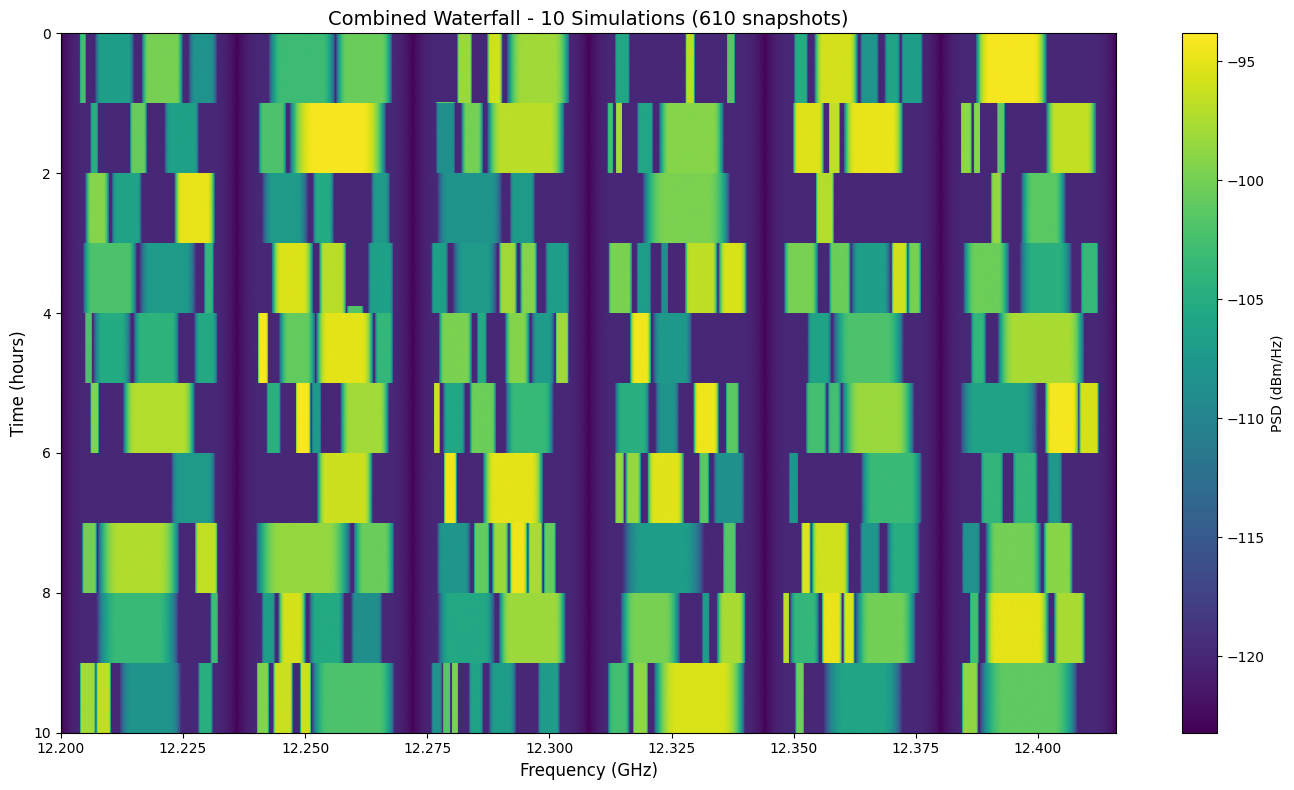


Summary:
  Total snapshots: 610
  Frequency bins: 2166
  Frequency range: 12.200 - 12.416 GHz
  Time range: 0.0 - 10.0 hours
  PSD range: -123.2 - -93.8 dBm/Hz


In [14]:
# Create waterfall plot from combined dataframe
import matplotlib.pyplot as plt

print("Creating waterfall plot from combined data...")

# Extract data for waterfall
num_snapshots = len(combined_df)
num_freq_bins = combined_df.iloc[0]['frequencies'].shape[0]

# Build time and frequency arrays
time_array = np.array([(t - combined_df.index[0]).total_seconds() / 60 for t in combined_df.index])  # Minutes
frequency_array = combined_df.iloc[0]['frequencies']

# Build PSD array (time x frequency)
psd_array = np.zeros((num_snapshots, num_freq_bins))
for i, (timestamp, row) in enumerate(combined_df.iterrows()):
    psd_array[i, :] = row['powers']

# Create waterfall plot
fig, ax = plt.subplots(figsize=(14, 8))

# Plot waterfall
extent = [
    frequency_array[0] / 1e9,  # Min frequency (GHz)
    frequency_array[-1] / 1e9,  # Max frequency (GHz)
    time_array[-1] / 60,  # Max time (hours)
    time_array[0] / 60  # Min time (hours)
]

im = ax.imshow(
    psd_array,
    aspect='auto',
    extent=extent,
    cmap='viridis',
    interpolation='nearest',
    origin='upper'
)

ax.set_xlabel('Frequency (GHz)', fontsize=12)
ax.set_ylabel('Time (hours)', fontsize=12)
ax.set_title(f'Combined Waterfall - {num_simulations} Simulations ({num_snapshots} snapshots)', fontsize=14)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, label='PSD (dBm/Hz)')

plt.tight_layout()
plt.savefig('../dev_output/combined_waterfall.png', dpi=150, bbox_inches='tight')
print(f"Waterfall plot saved to: ../dev_output/combined_waterfall.png")
plt.show()

# Print summary statistics
print(f"\nSummary:")
print(f"  Total snapshots: {num_snapshots}")
print(f"  Frequency bins: {num_freq_bins}")
print(f"  Frequency range: {frequency_array[0]/1e9:.3f} - {frequency_array[-1]/1e9:.3f} GHz")
print(f"  Time range: {time_array[0]/60:.1f} - {time_array[-1]/60:.1f} hours")
print(f"  PSD range: {np.min(psd_array):.1f} - {np.max(psd_array):.1f} dBm/Hz")

In [16]:
!pip install scikit-learn

  Using cached scikit_learn-1.7.2-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.4 MB)
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [17]:
# BIRCH Clustering with Feature Extraction
from sklearn.cluster import Birch
from scipy.signal import find_peaks

print("Extracting features from spectrum data...")

# Extract features for each row
features_list = []
for idx, row in combined_df.iterrows():
    frequencies = row['frequencies']
    powers = row['powers']
    
    # Feature extraction
    mean_power = np.mean(powers)
    max_power = np.max(powers)
    std_power = np.std(powers)
    median_power = np.median(powers)
    
    # Find peaks
    peaks, _ = find_peaks(powers, prominence=5)  # Prominence threshold for significant peaks
    num_peaks = len(peaks)
    
    # Spectral centroid (frequency-weighted average)
    spectral_centroid = np.sum(frequencies * powers) / np.sum(powers) if np.sum(powers) > 0 else 0
    
    # Power above threshold (occupied bandwidth indicator)
    threshold = mean_power + std_power
    power_above_threshold = np.sum(powers > threshold)
    
    features_list.append([
        mean_power,
        max_power,
        std_power,
        median_power,
        num_peaks,
        spectral_centroid,
        power_above_threshold
    ])

# Convert to numpy array
features = np.array(features_list)

print(f"Extracted {features.shape[1]} features from {features.shape[0]} samples")
print(f"Features: mean_power, max_power, std_power, median_power, num_peaks, spectral_centroid, power_above_threshold")

# Normalize features for clustering
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_normalized = scaler.fit_transform(features)

# Apply BIRCH clustering
print("\nApplying BIRCH clustering...")
birch = Birch(n_clusters=5, threshold=0.5, branching_factor=50)
cluster_labels = birch.fit_predict(features_normalized)

# Count clusters
unique_labels, counts = np.unique(cluster_labels, return_counts=True)
print(f"Found {len(unique_labels)} clusters")
for label, count in zip(unique_labels, counts):
    print(f"  Cluster {label}: {count} samples ({100*count/len(cluster_labels):.1f}%)")

# Add cluster labels to dataframe
combined_df['cluster'] = cluster_labels

Extracting features from spectrum data...
Extracted 7 features from 610 samples
Features: mean_power, max_power, std_power, median_power, num_peaks, spectral_centroid, power_above_threshold

Applying BIRCH clustering...
Found 5 clusters
  Cluster 0: 305 samples (50.0%)
  Cluster 1: 61 samples (10.0%)
  Cluster 2: 122 samples (20.0%)
  Cluster 3: 61 samples (10.0%)
  Cluster 4: 61 samples (10.0%)


Clustering visualization saved to: ../dev_output/birch_clustering_analysis.png


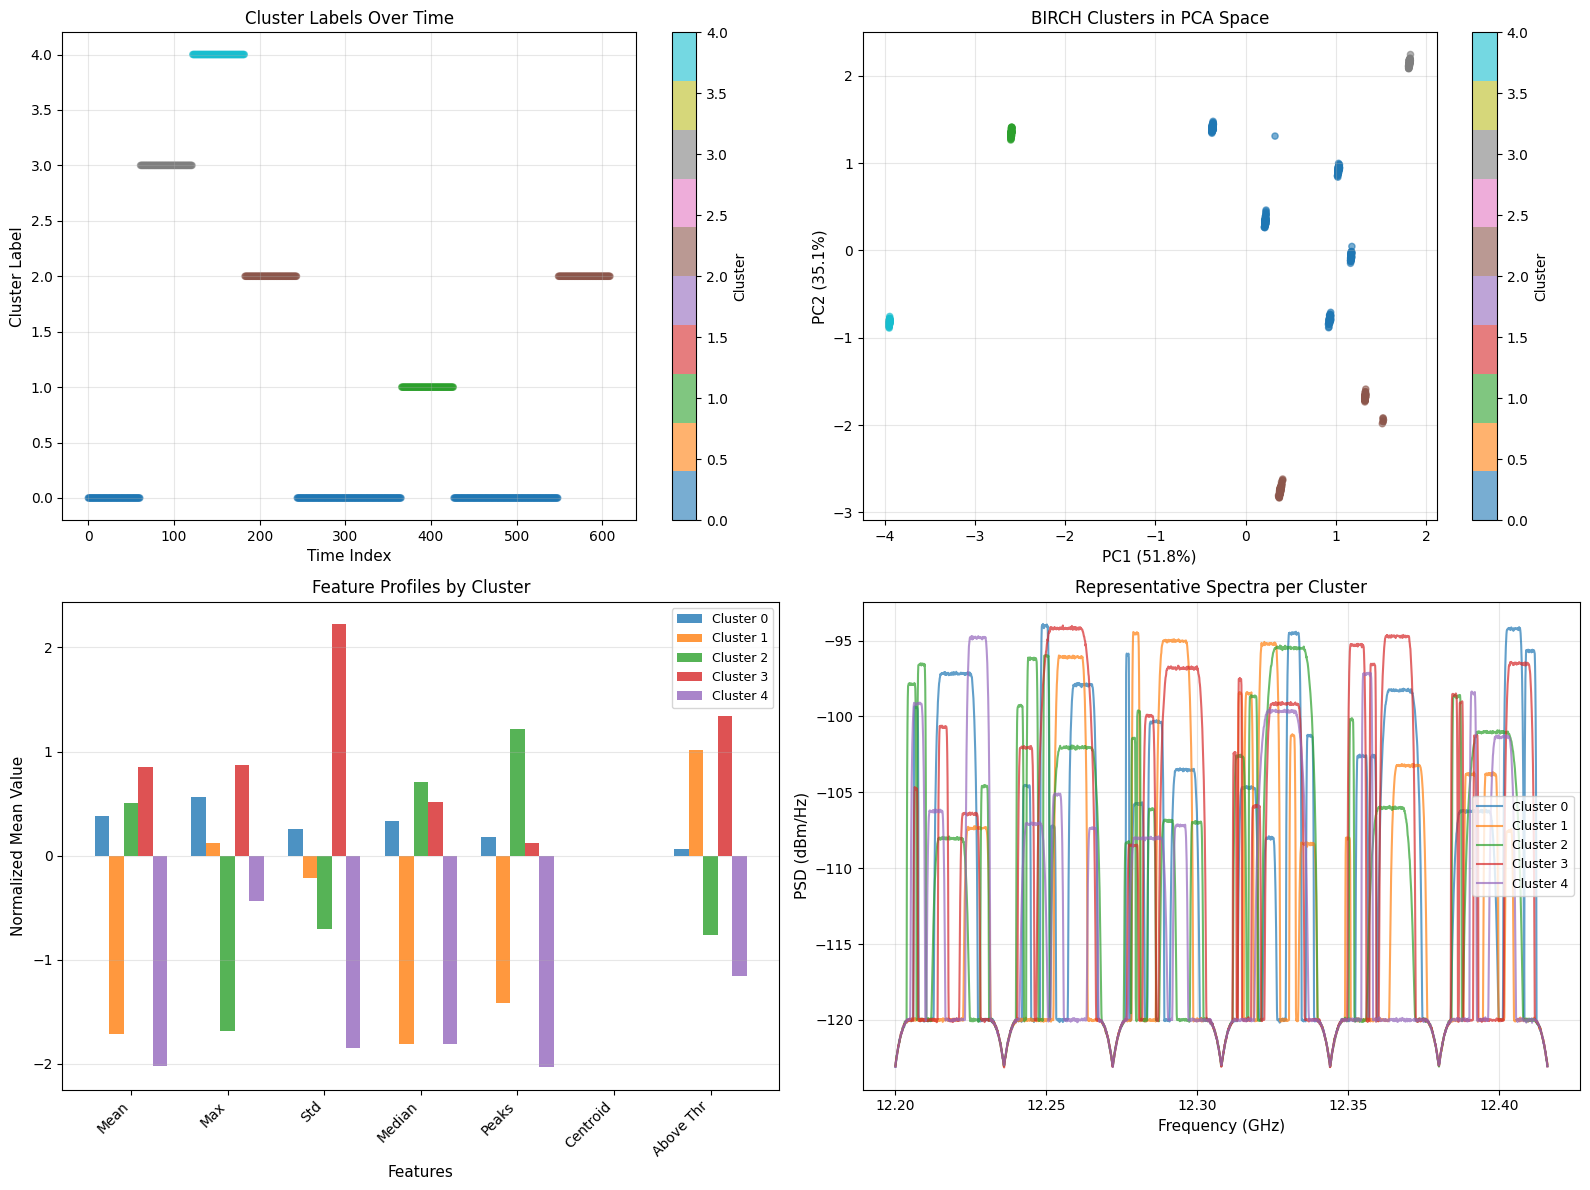

In [18]:
# Visualize clustering results
from sklearn.decomposition import PCA

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Cluster labels over time
ax1 = axes[0, 0]
time_indices = np.arange(len(cluster_labels))
scatter = ax1.scatter(time_indices, cluster_labels, c=cluster_labels, cmap='tab10', alpha=0.6, s=20)
ax1.set_xlabel('Time Index', fontsize=11)
ax1.set_ylabel('Cluster Label', fontsize=11)
ax1.set_title('Cluster Labels Over Time', fontsize=12)
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='Cluster')

# 2. PCA projection of features (2D)
ax2 = axes[0, 1]
pca = PCA(n_components=2)
features_2d = pca.fit_transform(features_normalized)
scatter2 = ax2.scatter(features_2d[:, 0], features_2d[:, 1], c=cluster_labels, cmap='tab10', alpha=0.6, s=20)
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
ax2.set_title('BIRCH Clusters in PCA Space', fontsize=12)
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=ax2, label='Cluster')

# 3. Feature importance (mean values per cluster)
ax3 = axes[1, 0]
feature_names = ['Mean', 'Max', 'Std', 'Median', 'Peaks', 'Centroid', 'Above Thr']
cluster_feature_means = []
for label in unique_labels:
    cluster_mask = cluster_labels == label
    cluster_feature_means.append(np.mean(features_normalized[cluster_mask], axis=0))

cluster_feature_means = np.array(cluster_feature_means)
x_pos = np.arange(len(feature_names))
width = 0.15
for i, label in enumerate(unique_labels):
    ax3.bar(x_pos + i*width, cluster_feature_means[i], width, label=f'Cluster {label}', alpha=0.8)

ax3.set_xlabel('Features', fontsize=11)
ax3.set_ylabel('Normalized Mean Value', fontsize=11)
ax3.set_title('Feature Profiles by Cluster', fontsize=12)
ax3.set_xticks(x_pos + width * 2)
ax3.set_xticklabels(feature_names, rotation=45, ha='right')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# 4. Example spectra from each cluster
ax4 = axes[1, 1]
for label in unique_labels[:5]:  # Show first 5 clusters
    cluster_mask = cluster_labels == label
    cluster_indices = np.where(cluster_mask)[0]
    
    if len(cluster_indices) > 0:
        # Get a representative sample (middle of cluster)
        sample_idx = cluster_indices[len(cluster_indices)//2]
        sample_row = combined_df.iloc[sample_idx]
        
        ax4.plot(sample_row['frequencies']/1e9, sample_row['powers'], 
                label=f'Cluster {label}', alpha=0.7, linewidth=1.5)

ax4.set_xlabel('Frequency (GHz)', fontsize=11)
ax4.set_ylabel('PSD (dBm/Hz)', fontsize=11)
ax4.set_title('Representative Spectra per Cluster', fontsize=12)
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../dev_output/birch_clustering_analysis.png', dpi=150, bbox_inches='tight')
print("Clustering visualization saved to: ../dev_output/birch_clustering_analysis.png")
plt.show()

In [17]:
# Create carrier patterns that repeat - this will make clustering more meaningful
print("Creating repeating carrier pattern configurations...\n")

# Define 5 distinct carrier patterns
carrier_patterns = {
    "Pattern_A": {
        "description": "Heavy low-frequency activity (Transponders 0-2)",
        "static_range": (5, 8),
        "dynamic_count": 3,
        "transponder_weights": np.array([2.0, 2.0, 2.0, 0.5, 0.5, 0.5])  # Bias toward 0-2
    },
    "Pattern_B": {
        "description": "Heavy high-frequency activity (Transponders 3-5)",
        "static_range": (5, 8),
        "dynamic_count": 3,
        "transponder_weights": np.array([0.5, 0.5, 0.5, 2.0, 2.0, 2.0])  # Bias toward 3-5
    },
    "Pattern_C": {
        "description": "Sparse activity across all transponders",
        "static_range": (2, 4),
        "dynamic_count": 2,
        "transponder_weights": np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0])  # Uniform
    },
    "Pattern_D": {
        "description": "Dense activity with many dynamic carriers",
        "static_range": (6, 9),
        "dynamic_count": 8,
        "transponder_weights": np.array([1.0, 1.5, 1.5, 1.0, 1.5, 1.0])  # Middle transponders
    },
    "Pattern_E": {
        "description": "Minimal activity (baseline)",
        "static_range": (1, 3),
        "dynamic_count": 1,
        "transponder_weights": np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0])  # Uniform
    }
}

# Print pattern descriptions
for pattern_name, pattern_config in carrier_patterns.items():
    print(f"{pattern_name}: {pattern_config['description']}")
    print(f"  Static carriers: {pattern_config['static_range']}")
    print(f"  Dynamic carriers: {pattern_config['dynamic_count']}")
    print()

Creating repeating carrier pattern configurations...

Pattern_A: Heavy low-frequency activity (Transponders 0-2)
  Static carriers: (5, 8)
  Dynamic carriers: 3

Pattern_B: Heavy high-frequency activity (Transponders 3-5)
  Static carriers: (5, 8)
  Dynamic carriers: 3

Pattern_C: Sparse activity across all transponders
  Static carriers: (2, 4)
  Dynamic carriers: 2

Pattern_D: Dense activity with many dynamic carriers
  Static carriers: (6, 9)
  Dynamic carriers: 8

Pattern_E: Minimal activity (baseline)
  Static carriers: (1, 3)
  Dynamic carriers: 1



In [18]:
# Generate simulations with repeating patterns (10 simulations, each pattern repeated 2x)
from datetime import timedelta

# Create pattern sequence: A, B, C, D, E, A, B, C, D, E (each pattern repeats)
pattern_sequence = ["Pattern_A", "Pattern_B", "Pattern_C", "Pattern_D", "Pattern_E",
                   "Pattern_A", "Pattern_B", "Pattern_C", "Pattern_D", "Pattern_E"]

num_simulations = len(pattern_sequence)
simulation_duration_min = 60  # 1 hour per simulation
all_dataframes_v2 = []
pattern_labels = []  # Track which pattern was used
current_start_time = datetime(2025, 1, 15, 0, 0, 0)

print(f"Running {num_simulations} simulations with repeating patterns...\n")

for i, pattern_name in enumerate(pattern_sequence):
    pattern = carrier_patterns[pattern_name]
    
    print(f"=== Simulation {i+1}/{num_simulations} - {pattern_name} ===")
    print(f"  {pattern['description']}")
    print(f"  Start time: {current_start_time}")
    
    # Generate carrier configuration with custom weights
    # We need to hack the generator to use our custom weights
    carrier_gen = CarrierGenerator(seed=42 + i)
    
    # Monkey-patch the _select_transponder method to use our weights
    original_select = carrier_gen._select_transponder
    def custom_select(already_allocated):
        weights = pattern['transponder_weights'] / pattern['transponder_weights'].sum()
        return carrier_gen.rng.choice(carrier_gen.num_transponders, p=weights)
    
    carrier_gen._select_transponder = custom_select
    
    # Generate carriers
    carrier_config = carrier_gen.generate_carriers(
        num_static_per_xpdr=pattern['static_range'],
        num_dynamic=pattern['dynamic_count']
    )
    
    # Create simulator
    simulator = PSDSimulator(
        carrier_config=carrier_config,
        interferer_configs=[],
        rbw_hz=100e3,
        vbw_hz=1e3
    )
    
    # Run simulation
    output_filepath = f"../dev_output/sim_pattern_{i+1:02d}_{pattern_name}_{current_start_time.strftime('%Y%m%d-%H%M%S')}.json"
    snapshots, metadata = simulator.run_simulation(
        duration_min=simulation_duration_min,
        snapshot_interval_min=1,
        start_datetime=current_start_time,
        export_json=True,
        output_filepath=output_filepath
    )
    
    # Load records and create dataframe
    records = SpectrumRecord.from_file(output_filepath)
    data_rows = []
    
    for record in records:
        freq_start = record.cf_hz - (record.bw_hz / 2)
        freq_end = record.cf_hz + (record.bw_hz / 2)
        frequencies = np.linspace(freq_start, freq_end, record.psd_shape[0])
        powers = record.get_psd()
        
        data_rows.append({
            'timestamp': record.timestamp,
            'cf_hz': record.cf_hz,
            'bw_hz': record.bw_hz,
            'rbw_hz': record.rbw_hz,
            'vbw_hz': record.vbw_hz,
            'frequencies': frequencies,
            'powers': powers,
            'pattern': pattern_name  # Track the pattern
        })
    
    df = pd.DataFrame(data_rows)
    df = df.set_index('timestamp')
    all_dataframes_v2.append(df)
    pattern_labels.extend([pattern_name] * len(df))
    
    # Update start time for next simulation
    current_start_time = current_start_time + timedelta(minutes=simulation_duration_min)
    print(f"  Completed. Next start time: {current_start_time}\n")

# Concatenate all dataframes
print("Concatenating all dataframes...")
combined_df_v2 = pd.concat(all_dataframes_v2, axis=0)
combined_df_v2['true_pattern'] = pattern_labels  # Add ground truth labels

print(f"Combined dataframe shape: {combined_df_v2.shape}")
print(f"Time range: {combined_df_v2.index[0]} to {combined_df_v2.index[-1]}")
print(f"Total duration: {(combined_df_v2.index[-1] - combined_df_v2.index[0]).total_seconds() / 3600:.1f} hours")
print(f"\nPattern distribution:")
print(combined_df_v2['true_pattern'].value_counts())

Running 10 simulations with repeating patterns...

=== Simulation 1/10 - Pattern_A ===
  Heavy low-frequency activity (Transponders 0-2)
  Start time: 2025-01-15 00:00:00
Generating static carriers...
  Created 24 static carriers
Generating 3 dynamic carriers...
  Created 1 dynamic carriers
Total carriers: 25
Initialized simulator with 6 transponders
  RBW: 100.0 kHz, VBW: 1.0 kHz

Running 1.0-hour simulation...
  Snapshot interval: 1.0 min
  Total snapshots: 61
  Processing t=0.0 hrs (1/61 snapshots, 2%)
  Processing t=0.2 hrs (13/61 snapshots, 21%)
  Processing t=0.4 hrs (25/61 snapshots, 41%)
  Processing t=0.6 hrs (37/61 snapshots, 61%)
  Processing t=0.8 hrs (49/61 snapshots, 80%)
  Processing t=1.0 hrs (61/61 snapshots, 100%)
  Completed 61 snapshots

  Exporting SpectrumRecord objects to JSON...
    Processing snapshot 1/61...
    Processing snapshot 13/61...
    Processing snapshot 25/61...
    Processing snapshot 37/61...
    Processing snapshot 49/61...
    Processing snapsho

In [19]:
# Extract features and apply clustering to the new pattern-based data
print("Extracting features from pattern-based spectrum data...")

# Extract features for each row
features_list_v2 = []
for idx, row in combined_df_v2.iterrows():
    frequencies = row['frequencies']
    powers = row['powers']
    
    # Feature extraction
    mean_power = np.mean(powers)
    max_power = np.max(powers)
    std_power = np.std(powers)
    median_power = np.median(powers)
    
    # Find peaks
    peaks, _ = find_peaks(powers, prominence=5)
    num_peaks = len(peaks)
    
    # Spectral centroid (frequency-weighted average)
    spectral_centroid = np.sum(frequencies * powers) / np.sum(powers) if np.sum(powers) > 0 else 0
    
    # Power above threshold (occupied bandwidth indicator)
    threshold = mean_power + std_power
    power_above_threshold = np.sum(powers > threshold)
    
    # Energy concentration (what fraction of energy is in low vs high frequencies)
    mid_freq = (frequencies[0] + frequencies[-1]) / 2
    low_freq_mask = frequencies < mid_freq
    high_freq_mask = frequencies >= mid_freq
    low_freq_energy = np.sum(powers[low_freq_mask])
    high_freq_energy = np.sum(powers[high_freq_mask])
    total_energy = low_freq_energy + high_freq_energy
    low_freq_ratio = low_freq_energy / total_energy if total_energy > 0 else 0.5
    
    features_list_v2.append([
        mean_power,
        max_power,
        std_power,
        median_power,
        num_peaks,
        spectral_centroid,
        power_above_threshold,
        low_freq_ratio
    ])

# Convert to numpy array
features_v2 = np.array(features_list_v2)

print(f"Extracted {features_v2.shape[1]} features from {features_v2.shape[0]} samples")
print(f"Features: mean_power, max_power, std_power, median_power, num_peaks, spectral_centroid, power_above_threshold, low_freq_ratio")

# Normalize features for clustering
scaler_v2 = StandardScaler()
features_normalized_v2 = scaler_v2.fit_transform(features_v2)

# Apply BIRCH clustering
print("\nApplying BIRCH clustering...")
birch_v2 = Birch(n_clusters=5, threshold=0.5, branching_factor=50)
cluster_labels_v2 = birch_v2.fit_predict(features_normalized_v2)

# Count clusters
unique_labels_v2, counts_v2 = np.unique(cluster_labels_v2, return_counts=True)
print(f"Found {len(unique_labels_v2)} clusters")
for label, count in zip(unique_labels_v2, counts_v2):
    print(f"  Cluster {label}: {count} samples ({100*count/len(cluster_labels_v2):.1f}%)")

# Add cluster labels to dataframe
combined_df_v2['cluster'] = cluster_labels_v2

# Check alignment between clusters and true patterns
print("\nCluster vs True Pattern confusion matrix:")
confusion_df = pd.crosstab(combined_df_v2['true_pattern'], combined_df_v2['cluster'], 
                          rownames=['True Pattern'], colnames=['Cluster'])
print(confusion_df)

Extracting features from pattern-based spectrum data...
Extracted 8 features from 610 samples
Features: mean_power, max_power, std_power, median_power, num_peaks, spectral_centroid, power_above_threshold, low_freq_ratio

Applying BIRCH clustering...
Found 5 clusters
  Cluster 0: 183 samples (30.0%)
  Cluster 1: 122 samples (20.0%)
  Cluster 2: 183 samples (30.0%)
  Cluster 3: 61 samples (10.0%)
  Cluster 4: 61 samples (10.0%)

Cluster vs True Pattern confusion matrix:
Cluster         0   1    2   3   4
True Pattern                      
Pattern_A       0   0  122   0   0
Pattern_B       0  61    0   0  61
Pattern_C      61   0    0  61   0
Pattern_D       0  61   61   0   0
Pattern_E     122   0    0   0   0


Cluster analysis plot saved to: ../dev_output/cluster_temporal_frequency_analysis.png


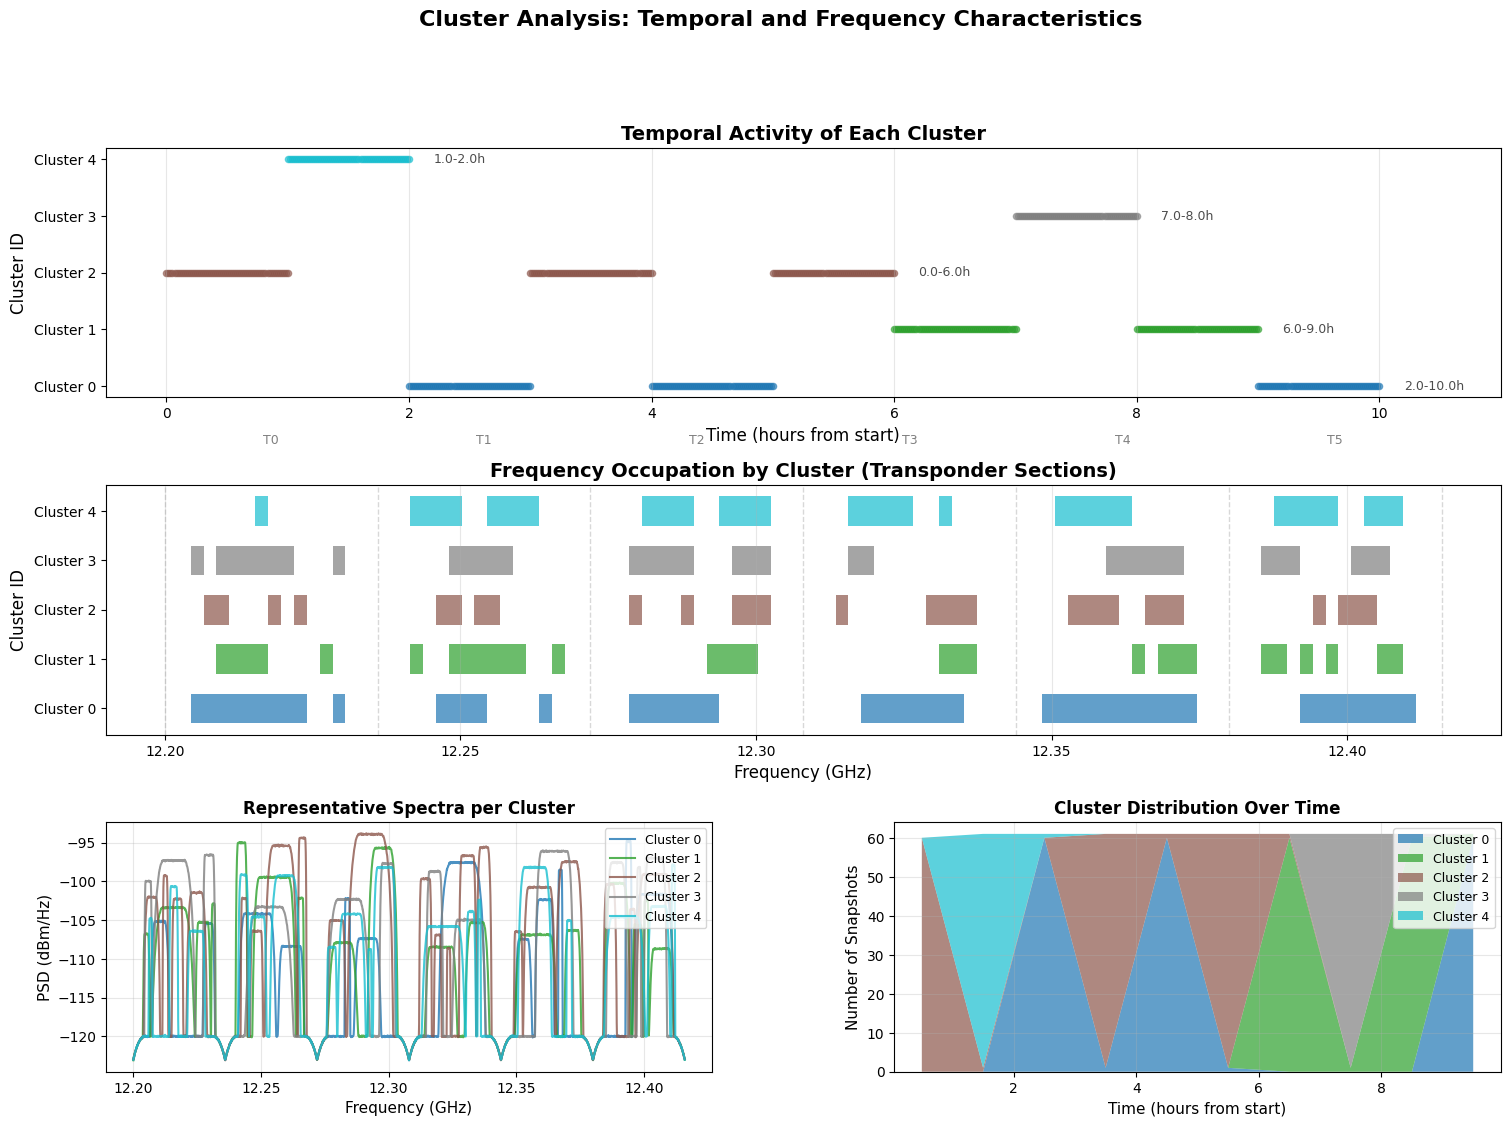

In [20]:
# Create comprehensive plots showing temporal and frequency characteristics of each cluster
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# Get time array in hours from start
time_in_hours = np.array([(t - combined_df_v2.index[0]).total_seconds() / 3600 
                          for t in combined_df_v2.index])

# Color map for clusters
cluster_colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels_v2)))

# 1. Timeline plot - when is each cluster active?
ax1 = fig.add_subplot(gs[0, :])
for cluster_idx, label in enumerate(unique_labels_v2):
    cluster_mask = combined_df_v2['cluster'] == label
    cluster_times = time_in_hours[cluster_mask]
    
    # Create horizontal bars showing active periods
    y_pos = cluster_idx
    ax1.scatter(cluster_times, np.ones_like(cluster_times) * y_pos, 
               c=[cluster_colors[cluster_idx]], alpha=0.6, s=20, label=f'Cluster {label}')
    
    # Add time range annotation
    if len(cluster_times) > 0:
        time_range = f"{cluster_times.min():.1f}-{cluster_times.max():.1f}h"
        ax1.text(cluster_times.max() + 0.2, y_pos, time_range, 
                va='center', fontsize=9, alpha=0.7)

ax1.set_xlabel('Time (hours from start)', fontsize=12)
ax1.set_ylabel('Cluster ID', fontsize=12)
ax1.set_title('Temporal Activity of Each Cluster', fontsize=14, fontweight='bold')
ax1.set_yticks(range(len(unique_labels_v2)))
ax1.set_yticklabels([f'Cluster {l}' for l in unique_labels_v2])
ax1.grid(True, alpha=0.3, axis='x')
ax1.set_xlim([-0.5, time_in_hours.max() + 1])

# 2. Frequency occupation plot - which transponder sections does each cluster use?
ax2 = fig.add_subplot(gs[1, :])

# Get transponder boundaries (6 transponders x 36 MHz each)
transponder_bw = 36e6
ku_band_start = 12.2e9
transponder_edges = []
for i in range(7):  # 6 transponders means 7 edges
    edge_freq = ku_band_start + i * transponder_bw
    transponder_edges.append(edge_freq / 1e9)  # Convert to GHz

# Plot transponder boundaries
for edge in transponder_edges:
    ax2.axvline(edge, color='gray', linestyle='--', alpha=0.3, linewidth=1)

# Add transponder labels
for i in range(6):
    center_freq = (transponder_edges[i] + transponder_edges[i+1]) / 2
    ax2.text(center_freq, len(unique_labels_v2) + 0.3, f'T{i}', 
            ha='center', va='bottom', fontsize=9, alpha=0.5)

# For each cluster, show the frequency ranges it occupies
for cluster_idx, label in enumerate(unique_labels_v2):
    cluster_mask = combined_df_v2['cluster'] == label
    cluster_data = combined_df_v2[cluster_mask]
    
    # Get all frequencies used by this cluster
    all_freqs = []
    all_powers = []
    for idx, row in cluster_data.iterrows():
        all_freqs.extend(row['frequencies'])
        all_powers.extend(row['powers'])
    
    all_freqs = np.array(all_freqs) / 1e9  # Convert to GHz
    all_powers = np.array(all_powers)
    
    # Find frequency bins with significant power
    freq_bins = np.linspace(all_freqs.min(), all_freqs.max(), 100)
    bin_powers = np.zeros(len(freq_bins) - 1)
    
    for i in range(len(freq_bins) - 1):
        bin_mask = (all_freqs >= freq_bins[i]) & (all_freqs < freq_bins[i+1])
        if bin_mask.any():
            bin_powers[i] = np.mean(all_powers[bin_mask])
    
    # Plot frequency occupation as horizontal bars
    y_pos = cluster_idx
    for i in range(len(freq_bins) - 1):
        if bin_powers[i] > np.percentile(all_powers, 60):  # Show bins above 60th percentile
            ax2.barh(y_pos, freq_bins[i+1] - freq_bins[i], left=freq_bins[i], 
                    height=0.6, color=cluster_colors[cluster_idx], alpha=0.7)

ax2.set_xlabel('Frequency (GHz)', fontsize=12)
ax2.set_ylabel('Cluster ID', fontsize=12)
ax2.set_title('Frequency Occupation by Cluster (Transponder Sections)', fontsize=14, fontweight='bold')
ax2.set_yticks(range(len(unique_labels_v2)))
ax2.set_yticklabels([f'Cluster {l}' for l in unique_labels_v2])
ax2.set_xlim([transponder_edges[0] - 0.01, transponder_edges[-1] + 0.01])
ax2.grid(True, alpha=0.3, axis='x')

# 3. Representative spectra for each cluster
ax3 = fig.add_subplot(gs[2, 0])
for cluster_idx, label in enumerate(unique_labels_v2):
    cluster_mask = combined_df_v2['cluster'] == label
    cluster_indices = np.where(cluster_mask)[0]
    
    if len(cluster_indices) > 0:
        # Get a representative sample (middle of cluster)
        sample_idx = cluster_indices[len(cluster_indices)//2]
        sample_row = combined_df_v2.iloc[sample_idx]
        
        ax3.plot(sample_row['frequencies']/1e9, sample_row['powers'], 
                color=cluster_colors[cluster_idx], label=f'Cluster {label}', 
                alpha=0.8, linewidth=1.5)

ax3.set_xlabel('Frequency (GHz)', fontsize=11)
ax3.set_ylabel('PSD (dBm/Hz)', fontsize=11)
ax3.set_title('Representative Spectra per Cluster', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9, loc='upper right')
ax3.grid(True, alpha=0.3)

# 4. Cluster distribution over time (stacked area chart)
ax4 = fig.add_subplot(gs[2, 1])

# Create time bins (1 hour bins)
time_bins = np.arange(0, time_in_hours.max() + 1, 1)
cluster_counts_over_time = np.zeros((len(unique_labels_v2), len(time_bins) - 1))

for i in range(len(time_bins) - 1):
    time_mask = (time_in_hours >= time_bins[i]) & (time_in_hours < time_bins[i+1])
    for cluster_idx, label in enumerate(unique_labels_v2):
        cluster_mask = combined_df_v2['cluster'] == label
        combined_mask = time_mask & cluster_mask
        cluster_counts_over_time[cluster_idx, i] = np.sum(combined_mask)

# Plot stacked area
bin_centers = (time_bins[:-1] + time_bins[1:]) / 2
ax4.stackplot(bin_centers, cluster_counts_over_time, 
             labels=[f'Cluster {l}' for l in unique_labels_v2],
             colors=cluster_colors, alpha=0.7)

ax4.set_xlabel('Time (hours from start)', fontsize=11)
ax4.set_ylabel('Number of Snapshots', fontsize=11)
ax4.set_title('Cluster Distribution Over Time', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9, loc='upper right')
ax4.grid(True, alpha=0.3)

plt.suptitle('Cluster Analysis: Temporal and Frequency Characteristics', 
            fontsize=16, fontweight='bold', y=0.995)

plt.savefig('../dev_output/cluster_temporal_frequency_analysis.png', 
           dpi=150, bbox_inches='tight')
print("Cluster analysis plot saved to: ../dev_output/cluster_temporal_frequency_analysis.png")
plt.show()

Analyzing transponder usage by cluster...

Cluster 0:
  Transponder 0:  26179 samples ( 22.0%)
  Transponder 1:  14230 samples ( 12.0%)
  Transponder 2:  10375 samples (  8.7%)
  Transponder 3:  25337 samples ( 21.3%)
  Transponder 4:  25146 samples ( 21.1%)
  Transponder 5:  17683 samples ( 14.9%)
  → Dominant transponders: T0 (22.0%), T3 (21.3%), T4 (21.1%)

Cluster 1:
  Transponder 0:  16921 samples ( 21.3%)
  Transponder 1:  14956 samples ( 18.9%)
  Transponder 2:  13836 samples ( 17.4%)
  Transponder 3:   9750 samples ( 12.3%)
  Transponder 4:   6893 samples (  8.7%)
  Transponder 5:  16944 samples ( 21.4%)
  → Dominant transponders: T0 (21.3%), T5 (21.4%)

Cluster 2:
  Transponder 0:  10238 samples (  8.6%)
  Transponder 1:  18108 samples ( 15.2%)
  Transponder 2:  25000 samples ( 21.0%)
  Transponder 3:  22262 samples ( 18.7%)
  Transponder 4:  16354 samples ( 13.7%)
  Transponder 5:  26988 samples ( 22.7%)
  → Dominant transponders: T2 (21.0%), T5 (22.7%)

Cluster 3:
  Transpon

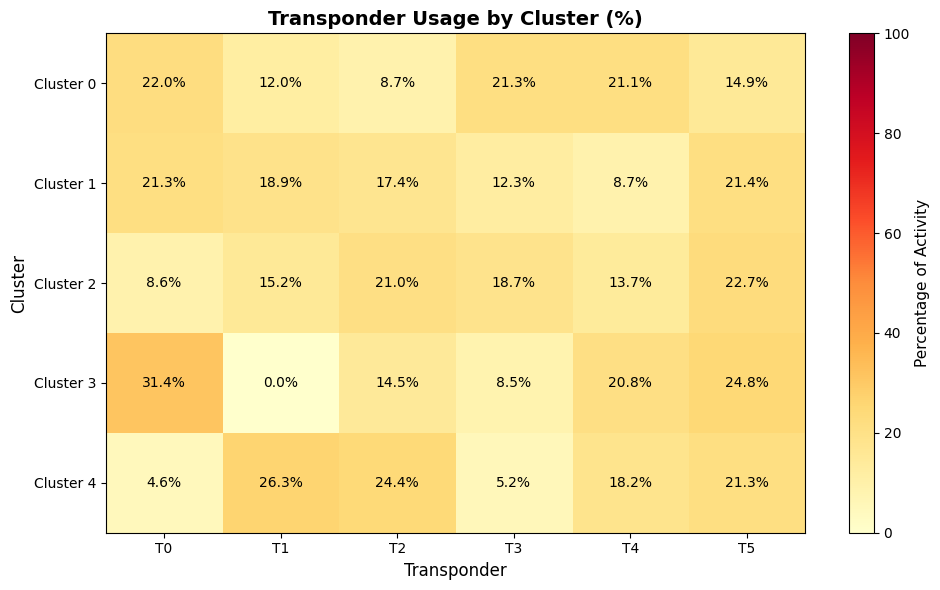

In [22]:
# Detailed analysis: Which transponders does each cluster primarily use?
print("Analyzing transponder usage by cluster...\n")

# Define transponder boundaries
transponder_bw = 36e6
ku_band_start = 12.2e9

def get_transponder_index(freq_hz):
    """Get transponder index (0-5) for a given frequency."""
    offset = freq_hz - ku_band_start
    idx = int(offset / transponder_bw)
    return max(0, min(5, idx))

# Analyze transponder usage for each cluster
transponder_usage = {label: {i: 0 for i in range(6)} for label in unique_labels_v2}

for cluster_idx, label in enumerate(unique_labels_v2):
    cluster_mask = combined_df_v2['cluster'] == label
    cluster_data = combined_df_v2[cluster_mask]
    
    for idx, row in cluster_data.iterrows():
        frequencies = row['frequencies']
        powers = row['powers']
        
        # Find which transponders have significant power
        for freq, power in zip(frequencies, powers):
            if power > np.percentile(powers, 70):  # Only count significant power
                xpdr_idx = get_transponder_index(freq)
                transponder_usage[label][xpdr_idx] += 1

# Print summary
for label in unique_labels_v2:
    total_counts = sum(transponder_usage[label].values())
    print(f"Cluster {label}:")
    
    # Find dominant transponders (>20% of activity)
    dominant = []
    for xpdr_idx in range(6):
        count = transponder_usage[label][xpdr_idx]
        percentage = 100 * count / total_counts if total_counts > 0 else 0
        if percentage > 20:
            dominant.append(f"T{xpdr_idx} ({percentage:.1f}%)")
        print(f"  Transponder {xpdr_idx}: {count:6d} samples ({percentage:5.1f}%)")
    
    if dominant:
        print(f"  → Dominant transponders: {', '.join(dominant)}")
    print()

# Create a heatmap visualization
fig, ax = plt.subplots(figsize=(10, 6))

# Build matrix: rows=clusters, cols=transponders
heatmap_data = np.zeros((len(unique_labels_v2), 6))
for cluster_idx, label in enumerate(unique_labels_v2):
    total_counts = sum(transponder_usage[label].values())
    for xpdr_idx in range(6):
        count = transponder_usage[label][xpdr_idx]
        heatmap_data[cluster_idx, xpdr_idx] = 100 * count / total_counts if total_counts > 0 else 0

# Plot heatmap
im = ax.imshow(heatmap_data, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)

# Add text annotations
for i in range(len(unique_labels_v2)):
    for j in range(6):
        text = ax.text(j, i, f'{heatmap_data[i, j]:.1f}%',
                      ha="center", va="center", color="black" if heatmap_data[i, j] < 50 else "white",
                      fontsize=10)

ax.set_xticks(range(6))
ax.set_xticklabels([f'T{i}' for i in range(6)])
ax.set_yticks(range(len(unique_labels_v2)))
ax.set_yticklabels([f'Cluster {l}' for l in unique_labels_v2])
ax.set_xlabel('Transponder', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title('Transponder Usage by Cluster (%)', fontsize=14, fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Percentage of Activity', fontsize=11)

plt.tight_layout()
plt.savefig('../dev_output/cluster_transponder_usage_heatmap.png', dpi=150, bbox_inches='tight')
print("Transponder usage heatmap saved to: ../dev_output/cluster_transponder_usage_heatmap.png")
plt.show()

In [24]:
# Generate a simulation with interferers affecting some carriers
from satellite_downlink_simulator.apps.rf_pattern_of_life_example.interferer_generator import InterfererConfig, InterfererType, SweepType

print("Creating simulation with interferers...\n")

# Generate carrier configuration
carrier_gen = CarrierGenerator(seed=100)
carrier_config = carrier_gen.generate_carriers(
    num_static_per_xpdr=(4, 7),
    num_dynamic=5
)

print(f"Generated {len(carrier_config.carriers)} carriers")

# Create interferer configurations manually for more control
interferer_configs = []

# Interferer 1: Continuous CW interferer in Transponder 1
# This simulates a persistent rogue carrier
interferer_configs.append(InterfererConfig(
    name="CW_Continuous_T1",
    transponder_idx=1,
    start_time_min=0.0,      # Start immediately
    end_time_min=30.0,       # Active for full 30 minutes
    cn_db=25.0,              # Strong interference
    interferer_type=InterfererType.CW.value,
    target_carrier_name=None,  # Independent interferer
    target_frequency_offset_hz=-5e6,  # 5 MHz below transponder center
    sweep_type=SweepType.NONE.value,
    sweep_rate_hz_per_min=0.0,
    sweep_range_hz=0.0,
    carrier=None  # CW interferer, not modulated
))

# Interferer 2: Periodic CW interferer (simulates radar sweeps)
# Active for 2 minutes every 5 minutes
interferer_configs.append(InterfererConfig(
    name="CW_Periodic_T4",
    transponder_idx=4,
    start_time_min=5.0,      # Start at 5 min
    end_time_min=7.0,        # Active for 2 minutes
    cn_db=28.0,              # Very strong
    interferer_type=InterfererType.CW.value,
    target_carrier_name=None,
    target_frequency_offset_hz=8e6,   # 8 MHz above center
    sweep_type=SweepType.NONE.value,
    sweep_rate_hz_per_min=0.0,
    sweep_range_hz=0.0,
    carrier=None
))

# Interferer 3: Same as #2 but appears again (periodic pattern)
interferer_configs.append(InterfererConfig(
    name="CW_Periodic_T4_Repeat1",
    transponder_idx=4,
    start_time_min=10.0,     # 5 min later
    end_time_min=12.0,
    cn_db=28.0,
    interferer_type=InterfererType.CW.value,
    target_carrier_name=None,
    target_frequency_offset_hz=8e6,
    sweep_type=SweepType.NONE.value,
    sweep_rate_hz_per_min=0.0,
    sweep_range_hz=0.0,
    carrier=None
))

interferer_configs.append(InterfererConfig(
    name="CW_Periodic_T4_Repeat2",
    transponder_idx=4,
    start_time_min=15.0,
    end_time_min=17.0,
    cn_db=28.0,
    interferer_type=InterfererType.CW.value,
    target_carrier_name=None,
    target_frequency_offset_hz=8e6,
    sweep_type=SweepType.NONE.value,
    sweep_rate_hz_per_min=0.0,
    sweep_range_hz=0.0,
    carrier=None
))

# Interferer 4: Sweeping CW interferer (simulates sweeping jammer)
interferer_configs.append(InterfererConfig(
    name="CW_Sweeping_T2",
    transponder_idx=2,
    start_time_min=10.0,
    end_time_min=25.0,       # Active for 15 minutes
    cn_db=22.0,
    interferer_type=InterfererType.CW.value,
    target_carrier_name=None,
    target_frequency_offset_hz=-10e6,  # Start 10 MHz below center
    sweep_type=SweepType.LINEAR.value,  # Linear sweep
    sweep_rate_hz_per_min=1.5e6,        # 1.5 MHz/min = 90 MHz/hour
    sweep_range_hz=0.0,                 # Not used for linear sweep
    carrier=None
))

# Interferer 5: Modulated interferer (simulates another satellite's signal bleeding in)
interferer_configs.append(InterfererConfig(
    name="MODULATED_Adjacent_T3",
    transponder_idx=3,
    start_time_min=5.0,
    end_time_min=20.0,
    cn_db=20.0,
    interferer_type=InterfererType.MODULATED.value,
    target_carrier_name=None,
    target_frequency_offset_hz=0,  # Right at transponder center
    sweep_type=SweepType.NONE.value,  # Modulated interferers don't sweep
    sweep_rate_hz_per_min=0.0,
    sweep_range_hz=0.0,
    carrier={
        'modulation': 'QPSK',
        'symbol_rate_sps': 8e6,  # 8 Msps
        'rrc_rolloff': 0.25
    }
))

print(f"Created {len(interferer_configs)} interferers:")
for i, config in enumerate(interferer_configs):
    print(f"  {i+1}. {config.name} (T{config.transponder_idx})")
    print(f"     Type: {config.interferer_type}, Active: {config.start_time_min:.1f}-{config.end_time_min:.1f} min")
    print(f"     CF offset: {config.target_frequency_offset_hz/1e6:.1f} MHz, C/N: {config.cn_db:.1f} dB")
    if config.sweep_type != SweepType.NONE.value:
        print(f"     Sweep: {config.sweep_type} ({config.sweep_rate_hz_per_min/1e6:.2f} MHz/min)")

# Create simulator with both carriers and interferers
simulator_with_interferers = PSDSimulator(
    carrier_config=carrier_config,
    interferer_configs=interferer_configs,
    rbw_hz=100e3,
    vbw_hz=1e3
)

# Run simulation
start_time = datetime(2025, 1, 20, 0, 0, 0)
output_filepath_interferers = f"../dev_output/spectrum_with_interferers_{start_time.strftime('%Y%m%d-%H%M%S')}.json"

print(f"\nRunning simulation with interferers (30 minutes)...")
snapshots_int, metadata_int = simulator_with_interferers.run_simulation(
    duration_min=30,
    snapshot_interval_min=0.5,  # 30 second intervals for better time resolution
    start_datetime=start_time,
    export_json=True,
    output_filepath=output_filepath_interferers
)

print(f"Simulation complete. Output saved to: {output_filepath_interferers}")

Creating simulation with interferers...

Generating static carriers...
  Created 14 static carriers
Generating 5 dynamic carriers...
  Created 3 dynamic carriers
Total carriers: 17
Generated 17 carriers
Created 6 interferers:
  1. CW_Continuous_T1 (T1)
     Type: cw, Active: 0.0-30.0 min
     CF offset: -5.0 MHz, C/N: 25.0 dB
  2. CW_Periodic_T4 (T4)
     Type: cw, Active: 5.0-7.0 min
     CF offset: 8.0 MHz, C/N: 28.0 dB
  3. CW_Periodic_T4_Repeat1 (T4)
     Type: cw, Active: 10.0-12.0 min
     CF offset: 8.0 MHz, C/N: 28.0 dB
  4. CW_Periodic_T4_Repeat2 (T4)
     Type: cw, Active: 15.0-17.0 min
     CF offset: 8.0 MHz, C/N: 28.0 dB
  5. CW_Sweeping_T2 (T2)
     Type: cw, Active: 10.0-25.0 min
     CF offset: -10.0 MHz, C/N: 22.0 dB
     Sweep: linear (1.50 MHz/min)
  6. MODULATED_Adjacent_T3 (T3)
     Type: modulated, Active: 5.0-20.0 min
     CF offset: 0.0 MHz, C/N: 20.0 dB
Initialized simulator with 6 transponders
  RBW: 100.0 kHz, VBW: 1.0 kHz

Running simulation with interferers

Loading and visualizing spectrum with interferers...
Loading spectrum records from: ../dev_output/spectrum_with_interferers_20250120-000000.json
  Loaded 61 spectrum records
  Time range: 0.0 - 30.0 minutes
  Frequency range: 12.200 - 12.416 GHz
  Frequency points: 2166
  Decompressing PSD data...
    Processing record 50/61
  PSD array shape: (61, 2166)
  Building activity log...
    Max carriers: 14
    Max interferers: 4
  Reconstructing metadata...
  Metadata summary:
    Duration: 30.0 minutes
    Snapshots: 61
    Interval: 0.5 minutes
    Total carriers: 14
    Total interferers: 6
Initialized visualizer
  Time range: 0.0 - 0.5 hrs
  Frequency range: 12.200 - 12.416 GHz
  PSD shape: (61, 2166)

Creating waterfall plot...
  PSD range: -121.0 to -95.1 dBm/Hz
  Saved to ../dev_output/waterfall_plot.png

Interferer activity summary:
  Total interferers: 6
  CW interferers: 5
  Modulated interferers: 1
  Sweeping interferers: 1

Visualization saved to: ../dev_output/interferer_visual

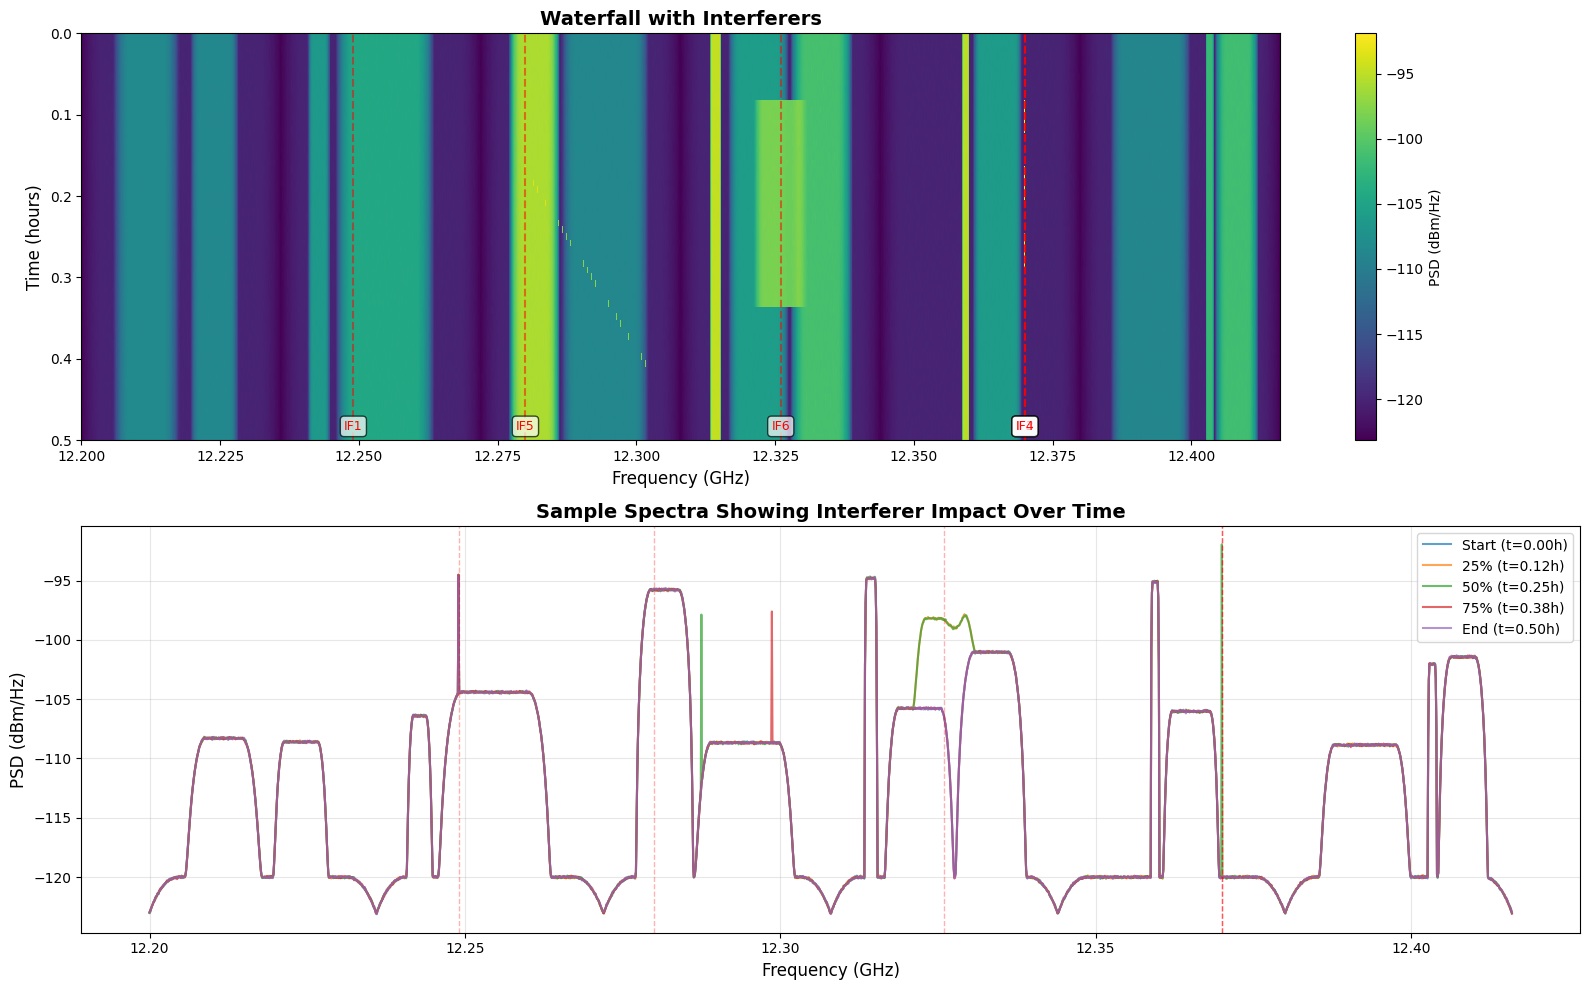

In [26]:
# Visualize the spectrum with interferers
print("Loading and visualizing spectrum with interferers...")

time_array_int, frequency_array_int, psd_array_int, metadata_int, activity_log_int, interferer_data_int = \
    load_and_process_records(output_filepath_interferers)

# Create visualizer
viz_int = Visualizer(
    time_array=time_array_int,
    frequency_array=frequency_array_int,
    psd_array=psd_array_int,
    metadata=metadata_int,
    output_dir="../dev_output/"
)

# Create waterfall plot showing interferers
viz_int.create_waterfall_plot()

print("\nInterferer activity summary:")
print(f"  Total interferers: {len(interferer_configs)}")
print(f"  CW interferers: {sum(1 for ic in interferer_configs if ic.interferer_type == 'cw')}")
print(f"  Modulated interferers: {sum(1 for ic in interferer_configs if ic.interferer_type == 'modulated')}")
print(f"  Sweeping interferers: {sum(1 for ic in interferer_configs if ic.sweep_type != 'none')}")

# Create a detailed comparison plot
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Top plot: Full waterfall with interferers
ax1 = axes[0]
extent = [
    frequency_array_int[0] / 1e9,
    frequency_array_int[-1] / 1e9,
    time_array_int[-1] / 60,
    time_array_int[0] / 60
]

im1 = ax1.imshow(
    psd_array_int,
    aspect='auto',
    extent=extent,
    cmap='viridis',
    interpolation='nearest',
    origin='upper'
)

ax1.set_xlabel('Frequency (GHz)', fontsize=12)
ax1.set_ylabel('Time (hours)', fontsize=12)
ax1.set_title('Waterfall with Interferers', fontsize=14, fontweight='bold')

# Mark interferer center frequencies and active times
# We need to calculate the absolute frequency for each interferer based on transponder
ku_band_start = 12.2e9
transponder_bw = 36e6

for i, config in enumerate(interferer_configs):
    # Calculate absolute frequency
    transponder_center = ku_band_start + (config.transponder_idx * transponder_bw) + (transponder_bw / 2)
    interferer_freq = transponder_center + config.target_frequency_offset_hz
    
    ax1.axvline(interferer_freq / 1e9, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
    ax1.text(interferer_freq / 1e9, extent[2] * 0.95, f'IF{i+1}', 
            color='red', fontsize=9, ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.colorbar(im1, ax=ax1, label='PSD (dBm/Hz)')

# Bottom plot: Sample spectra at different times showing interferer presence
ax2 = axes[1]

# Get snapshots at different times
num_snapshots = len(time_array_int)
sample_indices = [0, num_snapshots // 4, num_snapshots // 2, 3 * num_snapshots // 4, -1]
sample_labels = ['Start', '25%', '50%', '75%', 'End']

for idx, label in zip(sample_indices, sample_labels):
    time_val = time_array_int[idx] / 60  # Convert to hours
    ax2.plot(frequency_array_int / 1e9, psd_array_int[idx, :], 
            label=f'{label} (t={time_val:.2f}h)', alpha=0.7, linewidth=1.5)

# Mark interferer frequencies
for i, config in enumerate(interferer_configs):
    transponder_center = ku_band_start + (config.transponder_idx * transponder_bw) + (transponder_bw / 2)
    interferer_freq = transponder_center + config.target_frequency_offset_hz
    ax2.axvline(interferer_freq / 1e9, color='red', linestyle='--', alpha=0.3, linewidth=1)

ax2.set_xlabel('Frequency (GHz)', fontsize=12)
ax2.set_ylabel('PSD (dBm/Hz)', fontsize=12)
ax2.set_title('Sample Spectra Showing Interferer Impact Over Time', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10, loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../dev_output/interferer_visualization.png', dpi=150, bbox_inches='tight')
print("\nVisualization saved to: ../dev_output/interferer_visualization.png")
plt.show()

In [28]:
# Create dataframe from interferer spectrum data
print("Creating dataframe from interferer spectrum data...")

records_int = SpectrumRecord.from_file(output_filepath_interferers)
data_rows_int = []

for record in records_int:
    freq_start = record.cf_hz - (record.bw_hz / 2)
    freq_end = record.cf_hz + (record.bw_hz / 2)
    frequencies = np.linspace(freq_start, freq_end, record.psd_shape[0])
    powers = record.get_psd()
    
    data_rows_int.append({
        'timestamp': record.timestamp,
        'cf_hz': record.cf_hz,
        'bw_hz': record.bw_hz,
        'rbw_hz': record.rbw_hz,
        'vbw_hz': record.vbw_hz,
        'frequencies': frequencies,
        'powers': powers
    })

df_int = pd.DataFrame(data_rows_int)
df_int = df_int.set_index('timestamp')

print(f"Dataframe shape: {df_int.shape}")
print(f"Time range: {df_int.index[0]} to {df_int.index[-1]}")
print(f"Total duration: {(df_int.index[-1] - df_int.index[0]).total_seconds() / 60:.1f} minutes")

Creating dataframe from interferer spectrum data...
Dataframe shape: (61, 6)
Time range: 2025-01-20 00:00:00 to 2025-01-20 00:30:00
Total duration: 30.0 minutes


In [29]:
# Extract features from interferer spectrum data
print("Extracting features from interferer spectrum data...")

features_list_int = []
for idx, row in df_int.iterrows():
    frequencies = row['frequencies']
    powers = row['powers']
    
    # Feature extraction
    mean_power = np.mean(powers)
    max_power = np.max(powers)
    std_power = np.std(powers)
    median_power = np.median(powers)
    
    # Find peaks
    peaks, _ = find_peaks(powers, prominence=5)
    num_peaks = len(peaks)
    
    # Spectral centroid (frequency-weighted average)
    spectral_centroid = np.sum(frequencies * powers) / np.sum(powers) if np.sum(powers) > 0 else 0
    
    # Power above threshold (occupied bandwidth indicator)
    threshold = mean_power + std_power
    power_above_threshold = np.sum(powers > threshold)
    
    # Energy concentration (what fraction of energy is in low vs high frequencies)
    mid_freq = (frequencies[0] + frequencies[-1]) / 2
    low_freq_mask = frequencies < mid_freq
    high_freq_mask = frequencies >= mid_freq
    low_freq_energy = np.sum(powers[low_freq_mask])
    high_freq_energy = np.sum(powers[high_freq_mask])
    total_energy = low_freq_energy + high_freq_energy
    low_freq_ratio = low_freq_energy / total_energy if total_energy > 0 else 0.5
    
    # Peak power ratio (max power relative to mean)
    peak_power_ratio = (max_power - mean_power) / (std_power + 1e-10)
    
    features_list_int.append([
        mean_power,
        max_power,
        std_power,
        median_power,
        num_peaks,
        spectral_centroid,
        power_above_threshold,
        low_freq_ratio,
        peak_power_ratio
    ])

# Convert to numpy array
features_int = np.array(features_list_int)

print(f"Extracted {features_int.shape[1]} features from {features_int.shape[0]} samples")
print(f"Features: mean_power, max_power, std_power, median_power, num_peaks, spectral_centroid, power_above_threshold, low_freq_ratio, peak_power_ratio")

# Normalize features for clustering
scaler_int = StandardScaler()
features_normalized_int = scaler_int.fit_transform(features_int)

# Apply BIRCH clustering
print("\nApplying BIRCH clustering to interferer data...")
birch_int = Birch(n_clusters=6, threshold=0.5, branching_factor=50)
cluster_labels_int = birch_int.fit_predict(features_normalized_int)

# Count clusters
unique_labels_int, counts_int = np.unique(cluster_labels_int, return_counts=True)
print(f"Found {len(unique_labels_int)} clusters")
for label, count in zip(unique_labels_int, counts_int):
    print(f"  Cluster {label}: {count} samples ({100*count/len(cluster_labels_int):.1f}%)")

# Add cluster labels to dataframe
df_int['cluster'] = cluster_labels_int

Extracting features from interferer spectrum data...
Extracted 9 features from 61 samples
Features: mean_power, max_power, std_power, median_power, num_peaks, spectral_centroid, power_above_threshold, low_freq_ratio, peak_power_ratio

Applying BIRCH clustering to interferer data...
Found 5 clusters
  Cluster 0: 28 samples (45.9%)
  Cluster 1: 15 samples (24.6%)
  Cluster 2: 14 samples (23.0%)
  Cluster 3: 2 samples (3.3%)
  Cluster 4: 2 samples (3.3%)


/home/harris/dev/rf-ml-v3/rf-ml/venv/lib/python3.13/site-packages/sklearn/cluster/_birch.py:730: ConvergenceWarning: Number of subclusters found (5) by BIRCH is less than (6). Decrease the threshold.
  warnings.warn(


Creating clustering visualizations for interferer data...
Interferer clustering analysis saved to: ../dev_output/interferer_clustering_analysis.png


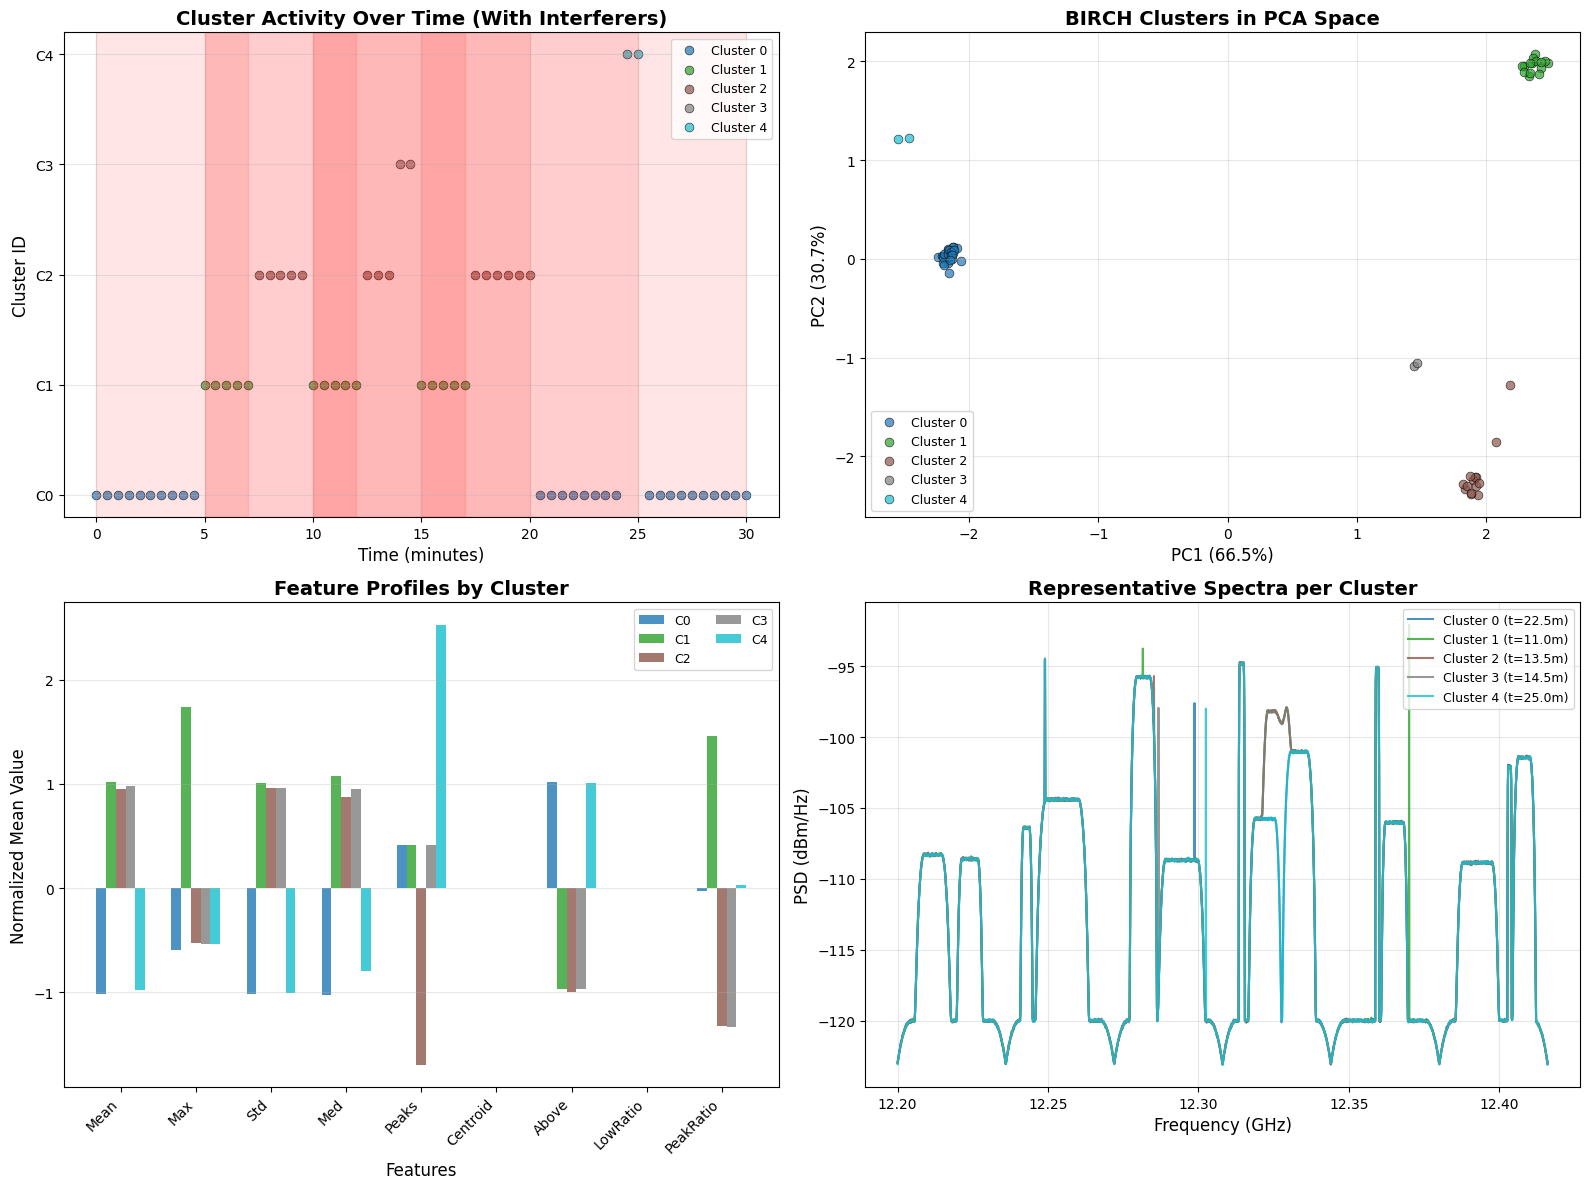

In [30]:
# Visualize clustering results for interferer data
print("Creating clustering visualizations for interferer data...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Get time array in minutes from start
time_in_minutes = np.array([(t - df_int.index[0]).total_seconds() / 60 
                            for t in df_int.index])

# Color map for clusters
cluster_colors_int = plt.cm.tab10(np.linspace(0, 1, len(unique_labels_int)))

# 1. Cluster labels over time
ax1 = axes[0, 0]
for cluster_idx, label in enumerate(unique_labels_int):
    cluster_mask = df_int['cluster'] == label
    cluster_times = time_in_minutes[cluster_mask]
    
    ax1.scatter(cluster_times, np.ones_like(cluster_times) * cluster_idx, 
               c=[cluster_colors_int[cluster_idx]], alpha=0.7, s=40, 
               label=f'Cluster {label}', edgecolors='black', linewidths=0.5)

ax1.set_xlabel('Time (minutes)', fontsize=12)
ax1.set_ylabel('Cluster ID', fontsize=12)
ax1.set_title('Cluster Activity Over Time (With Interferers)', fontsize=14, fontweight='bold')
ax1.set_yticks(range(len(unique_labels_int)))
ax1.set_yticklabels([f'C{l}' for l in unique_labels_int])
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9, loc='upper right')

# Add interferer active regions as background shading
for i, config in enumerate(interferer_configs):
    ax1.axvspan(config.start_time_min, config.end_time_min, 
               alpha=0.1, color='red', label=f'IF{i+1}' if i < 2 else '')

# 2. PCA projection
ax2 = axes[0, 1]
pca_int = PCA(n_components=2)
features_2d_int = pca_int.fit_transform(features_normalized_int)

for cluster_idx, label in enumerate(unique_labels_int):
    cluster_mask = cluster_labels_int == label
    ax2.scatter(features_2d_int[cluster_mask, 0], features_2d_int[cluster_mask, 1], 
               c=[cluster_colors_int[cluster_idx]], alpha=0.7, s=40,
               label=f'Cluster {label}', edgecolors='black', linewidths=0.5)

ax2.set_xlabel(f'PC1 ({pca_int.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax2.set_ylabel(f'PC2 ({pca_int.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax2.set_title('BIRCH Clusters in PCA Space', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)

# 3. Feature profiles by cluster
ax3 = axes[1, 0]
feature_names = ['Mean', 'Max', 'Std', 'Med', 'Peaks', 'Centroid', 'Above', 'LowRatio', 'PeakRatio']
cluster_feature_means_int = []

for label in unique_labels_int:
    cluster_mask = cluster_labels_int == label
    cluster_feature_means_int.append(np.mean(features_normalized_int[cluster_mask], axis=0))

cluster_feature_means_int = np.array(cluster_feature_means_int)
x_pos = np.arange(len(feature_names))
width = 0.13

for i, label in enumerate(unique_labels_int):
    ax3.bar(x_pos + i*width, cluster_feature_means_int[i], width, 
           label=f'C{label}', alpha=0.8, color=cluster_colors_int[i])

ax3.set_xlabel('Features', fontsize=12)
ax3.set_ylabel('Normalized Mean Value', fontsize=12)
ax3.set_title('Feature Profiles by Cluster', fontsize=14, fontweight='bold')
ax3.set_xticks(x_pos + width * (len(unique_labels_int)-1) / 2)
ax3.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=10)
ax3.legend(fontsize=9, ncol=2)
ax3.grid(True, alpha=0.3, axis='y')

# 4. Representative spectra per cluster
ax4 = axes[1, 1]

for cluster_idx, label in enumerate(unique_labels_int):
    cluster_mask = df_int['cluster'] == label
    cluster_indices = np.where(cluster_mask)[0]
    
    if len(cluster_indices) > 0:
        # Get a representative sample (middle of cluster)
        sample_idx = cluster_indices[len(cluster_indices)//2]
        sample_row = df_int.iloc[sample_idx]
        
        ax4.plot(sample_row['frequencies']/1e9, sample_row['powers'], 
                label=f'Cluster {label} (t={time_in_minutes[sample_idx]:.1f}m)', 
                alpha=0.8, linewidth=1.5, color=cluster_colors_int[cluster_idx])

ax4.set_xlabel('Frequency (GHz)', fontsize=12)
ax4.set_ylabel('PSD (dBm/Hz)', fontsize=12)
ax4.set_title('Representative Spectra per Cluster', fontsize=14, fontweight='bold')
ax4.legend(fontsize=9, loc='upper right')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../dev_output/interferer_clustering_analysis.png', dpi=150, bbox_inches='tight')
print("Interferer clustering analysis saved to: ../dev_output/interferer_clustering_analysis.png")
plt.show()

Analyzing cluster correspondence with interferer activity...

Cluster distribution by number of active interferers:
Cluster         0   1  2  3  4
# Interferers                 
1              20   0  0  0  0
2               8   0  5  0  2
3               0   5  9  2  0
4               0  10  0  0  0

Cluster characteristics:

Cluster 0 (28 samples):
  Time range: 0.0 - 30.0 minutes
  Interferer activity:
    1 interferers: 20 samples (71.4%)
    2 interferers: 8 samples (28.6%)
  Most common interferer combinations:
    'IF1': 20 samples (71.4%)
    'IF1,IF5': 8 samples (28.6%)

Cluster 1 (15 samples):
  Time range: 5.0 - 17.0 minutes
  Interferer activity:
    3 interferers: 5 samples (33.3%)
    4 interferers: 10 samples (66.7%)
  Most common interferer combinations:
    'IF1,IF2,IF6': 5 samples (33.3%)
    'IF1,IF3,IF5,IF6': 5 samples (33.3%)
    'IF1,IF4,IF5,IF6': 5 samples (33.3%)

Cluster 2 (14 samples):
  Time range: 7.5 - 20.0 minutes
  Interferer activity:
    2 interferers: 

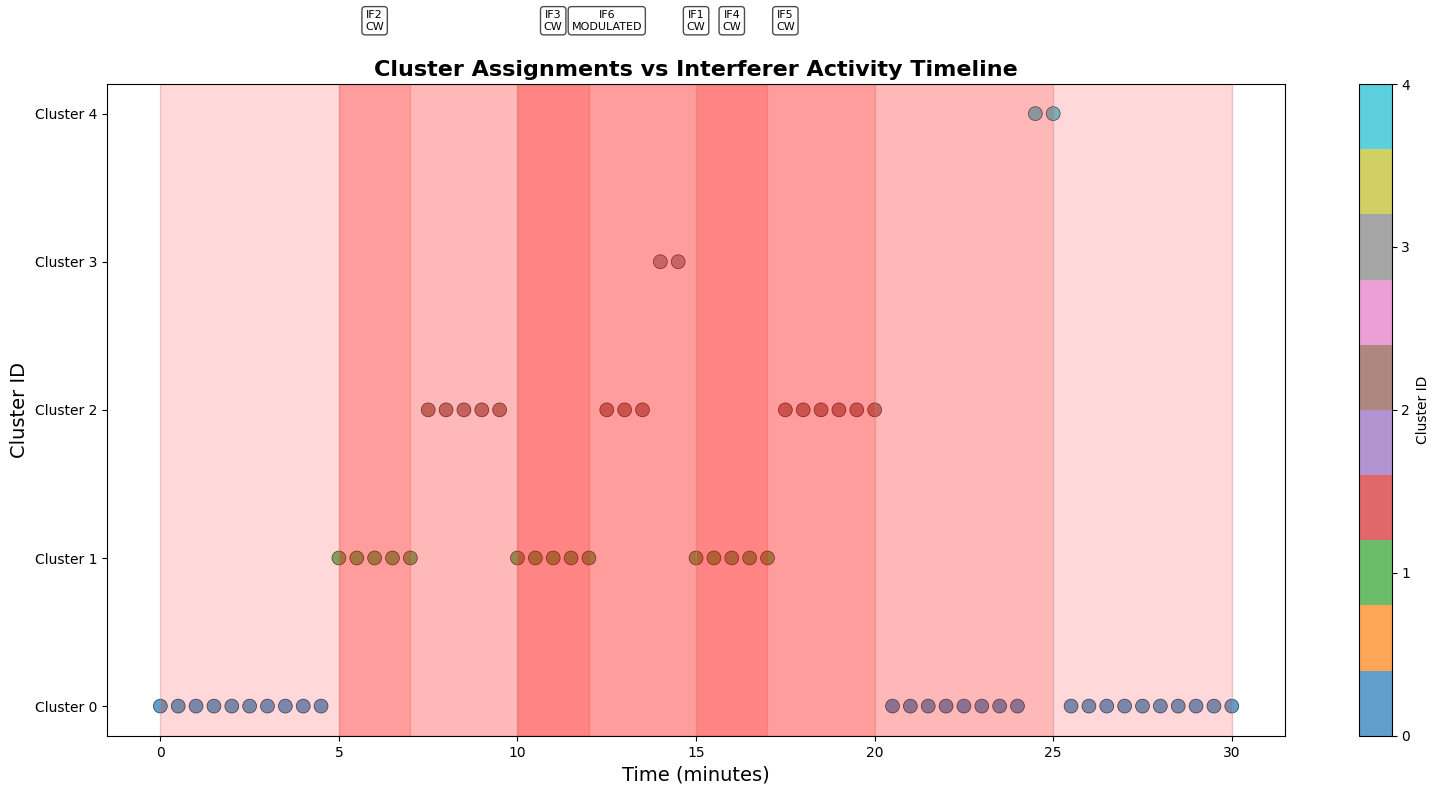

In [31]:
# Analyze which clusters correspond to interferer activity
print("Analyzing cluster correspondence with interferer activity...\n")

# Create a timeline showing which interferers are active at each time
df_int['active_interferers'] = ''
df_int['num_active_interferers'] = 0

for idx, row in df_int.iterrows():
    time_min = (idx - df_int.index[0]).total_seconds() / 60
    active = []
    
    for i, config in enumerate(interferer_configs):
        if config.start_time_min <= time_min <= config.end_time_min:
            active.append(f'IF{i+1}')
    
    df_int.at[idx, 'active_interferers'] = ','.join(active) if active else 'None'
    df_int.at[idx, 'num_active_interferers'] = len(active)

# Analyze cluster vs interferer activity
print("Cluster distribution by number of active interferers:")
cluster_by_interferer_count = pd.crosstab(
    df_int['num_active_interferers'], 
    df_int['cluster'],
    rownames=['# Interferers'],
    colnames=['Cluster']
)
print(cluster_by_interferer_count)

print("\n" + "="*80)
print("Cluster characteristics:\n")

for label in unique_labels_int:
    cluster_mask = df_int['cluster'] == label
    cluster_data = df_int[cluster_mask]
    
    print(f"Cluster {label} ({len(cluster_data)} samples):")
    
    # Time range
    time_range_min = [(t - df_int.index[0]).total_seconds() / 60 for t in cluster_data.index]
    print(f"  Time range: {min(time_range_min):.1f} - {max(time_range_min):.1f} minutes")
    
    # Interferer activity
    interferer_counts = cluster_data['num_active_interferers'].value_counts()
    print(f"  Interferer activity:")
    for count in sorted(interferer_counts.index):
        percentage = 100 * interferer_counts[count] / len(cluster_data)
        print(f"    {count} interferers: {interferer_counts[count]} samples ({percentage:.1f}%)")
    
    # Most common interferer combinations
    active_combos = cluster_data['active_interferers'].value_counts().head(3)
    print(f"  Most common interferer combinations:")
    for combo, count in active_combos.items():
        percentage = 100 * count / len(cluster_data)
        print(f"    '{combo}': {count} samples ({percentage:.1f}%)")
    
    print()

# Create visualization showing cluster vs interferer timeline
fig, ax = plt.subplots(figsize=(16, 8))

# Plot clusters over time
time_minutes = np.array([(t - df_int.index[0]).total_seconds() / 60 for t in df_int.index])
cluster_array = df_int['cluster'].values

# Create scatter plot with color showing cluster
scatter = ax.scatter(time_minutes, cluster_array, 
                    c=cluster_array, cmap='tab10', 
                    s=100, alpha=0.7, edgecolors='black', linewidths=0.5)

# Add interferer activity as vertical regions
for i, config in enumerate(interferer_configs):
    ax.axvspan(config.start_time_min, config.end_time_min, 
              alpha=0.15, color='red')
    
    # Add label at top
    mid_time = (config.start_time_min + config.end_time_min) / 2
    ax.text(mid_time, len(unique_labels_int) - 0.3, 
           f'IF{i+1}\n{config.name.split("_")[0]}', 
           ha='center', va='top', fontsize=8, 
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax.set_xlabel('Time (minutes)', fontsize=14)
ax.set_ylabel('Cluster ID', fontsize=14)
ax.set_title('Cluster Assignments vs Interferer Activity Timeline', 
            fontsize=16, fontweight='bold')
ax.set_yticks(range(len(unique_labels_int)))
ax.set_yticklabels([f'Cluster {l}' for l in unique_labels_int])
ax.grid(True, alpha=0.3, axis='x')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, label='Cluster ID', 
                   ticks=unique_labels_int)

plt.tight_layout()
plt.savefig('../dev_output/cluster_interferer_timeline.png', dpi=150, bbox_inches='tight')
print("="*80)
print("Cluster vs interferer timeline saved to: ../dev_output/cluster_interferer_timeline.png")
plt.show()